# Pnemonia Classifier Using Pytorch

In [1]:
import zipfile

with zipfile.ZipFile("/content/Pneumonia Dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/data")

In [12]:
import os

print(os.listdir("/content/data"))

['data']


## Installing and Importing Essential Packages

In [23]:
import os

import matplotlib.pyplot as plt

import seaborn as sns

from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Loading the Dataset and Inspecting the Data

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [25]:
device

device(type='cuda')

In [26]:
class PneumoniaDataset(Dataset):
  def __init__(self, root_dir, transform = None):
    self.root_dir = root_dir
    self.transform = transform
    self.image_paths = []
    self.labels = []

    dataset_classes = ["NORMAL", "PNEUMONIA"]
    # data/train/NORMAL/img1.png
    for label in dataset_classes:
      class_dir = os.path.join(root_dir, label)
      for img_name in os.listdir(class_dir):
        self.image_paths.append(os.path.join(class_dir, img_name))
        self.labels.append(0 if label == "NORMAL" else 1)

  def __len__(self):
    return len(self.labels)

  def __getitem__(self, idx):
    image = Image.open(self.image_paths[idx]).convert("RGB")
    if self.transform:
      image = self.transform(image)

    label = self.labels[idx]

    return image, label

  def get_image(self, idx):
    return self.image_paths[idx]

In [27]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [28]:
train_dataset = PneumoniaDataset("/content/data/data/train", transform)
val_dataset = PneumoniaDataset("/content/data/data/val", transform)
test_dataset = PneumoniaDataset("/content/data/data/test", transform)

In [29]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle = False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False, num_workers=2, pin_memory=True)

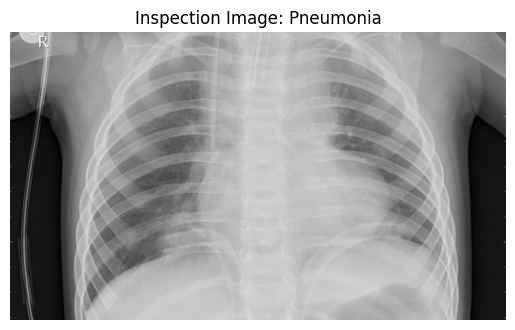

In [30]:
inspection_img_path = train_dataset.get_image(idx = 5000)
inspection_img = Image.open(inspection_img_path)
_, inspection_img_label = train_dataset.__getitem__(5000)

plt.title(f"Inspection Image: {"Normal" if inspection_img_label == 0 else "Pneumonia"}")

plt.imshow(inspection_img, cmap = "gray")
plt.axis("off")

plt.show()

## Trasfer Learning (Resnet 18) and Training the Model with Penumonia Dataset

In [31]:
model = models.resnet18(weights = models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 2) # 2 => Normal and Pneumonia
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [32]:
epochs = 10

for epoch in range(epochs):
  model.train()

  running_loss = 0.0
  train_correct = 0
  train_total = 0

  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    running_loss += loss.item()

    _, preds = torch.max(outputs, 1)
    train_correct += (preds == labels).sum().item()
    train_total += labels.size(0)

  train_loss = running_loss / len(train_loader)
  train_acc = train_correct / train_total

  model.eval()
  val_labels = []
  val_preds = []
  val_loss = 0.0

  with torch.no_grad():
    for images, labels in val_loader:
      images = images.to(device)
      labels = labels.to(device)

      outputs = model(images)
      loss = criterion(outputs, labels)
      val_loss += loss.item()

      _, preds = torch.max(outputs, 1)

      val_labels.extend(labels.cpu().numpy())
      val_preds.extend(preds.cpu().numpy())

  val_accuracy = accuracy_score(val_labels, val_preds)
  print(f"Epoch: {epoch + 1}/{epochs}, loss: {train_loss}, val_loss:{val_loss / len(val_loader)}, accuracy: {train_acc}, val_accuracy: {val_accuracy}")


Epoch: 1/10, loss: 0.1286034448885793, val_loss:0.0525566041469574, accuracy: 0.9493865030674846, val_accuracy: 1.0
Epoch: 2/10, loss: 0.06636530565000796, val_loss:0.3631740212440491, accuracy: 0.9748849693251533, val_accuracy: 0.8125
Epoch: 3/10, loss: 0.04281588678571047, val_loss:0.2450515329837799, accuracy: 0.9840874233128835, val_accuracy: 0.875
Epoch: 4/10, loss: 0.04569948562549461, val_loss:0.030883606523275375, accuracy: 0.9827453987730062, val_accuracy: 1.0
Epoch: 5/10, loss: 0.024803831232740242, val_loss:0.005759278312325478, accuracy: 0.9904141104294478, val_accuracy: 1.0
Epoch: 6/10, loss: 0.03825527981053638, val_loss:0.19702598452568054, accuracy: 0.986579754601227, val_accuracy: 0.875
Epoch: 7/10, loss: 0.033566556156732916, val_loss:0.2759201228618622, accuracy: 0.9898389570552147, val_accuracy: 0.875
Epoch: 8/10, loss: 0.016084767331242807, val_loss:0.009503599256277084, accuracy: 0.9934815950920245, val_accuracy: 1.0
Epoch: 9/10, loss: 0.013067856012450111, val_lo

## Model Evaluation on Test Data

In [34]:
model.eval()

test_labels = []
test_preds = []

with torch.no_grad():
  for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    test_labels.extend(labels.cpu().numpy())
    test_preds.extend(preds.cpu().numpy())

test_accuracy = accuracy_score(test_labels, test_preds)
print(f"Test Accuracy: {test_accuracy}")

torch.save(model.state_dict(), "/content/pneumonia_classifier_pytorch.pth")

Test Accuracy: 0.7644230769230769


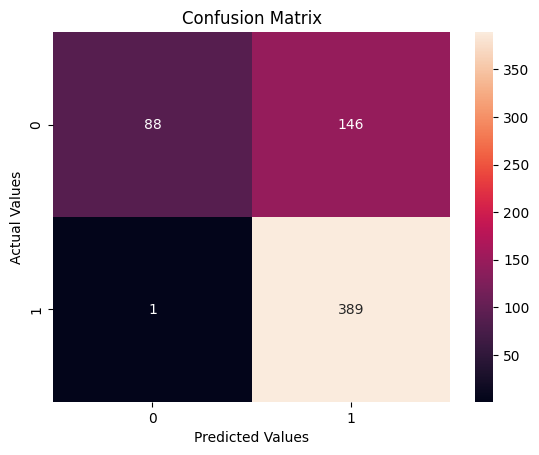

              precision    recall  f1-score   support

           0       0.99      0.38      0.54       234
           1       0.73      1.00      0.84       390

    accuracy                           0.76       624
   macro avg       0.86      0.69      0.69       624
weighted avg       0.83      0.76      0.73       624



In [36]:
cm = confusion_matrix(test_labels, test_preds)

plt.title("Confusion Matrix")

sns.heatmap(cm, annot = True, fmt='d')
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")

plt.show()

print(classification_report(test_labels, test_preds))